In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

df_news_final_project = pd.read_parquet(
    "/content/drive/MyDrive/NLP_AI_Impact_Project/data/industry_labeled.parquet"
)

print(df_news_final_project.shape)
df_news_final_project.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(188910, 10)


,url,date,language,title,text,word_count,clean_text,processed_text,topic,industry
0,https://blockworks.co/price/bad,2025-06-23,en,"Bad Idea AI Price (BAD), Market Cap, Price Tod...","Bad Idea AI Price (BAD), Market Cap, Price Tod...",483,"Bad Idea AI Price (BAD), Market Cap, Price Tod...",bad idea ai price bad market cap price today c...,1,Other
1,https://boingboing.net/2024/07/01/this-ai-vide...,2024-07-01,en,This AI video of gymnastics might be the freak...,\n\nThis AI video of gymnastics might be the f...,812,\n\nThis AI video of gymnastics might be the f...,this ai video of gymnastics might be the frea...,11,Other
2,https://boingboing.net/2024/09/18/if-using-ai-...,2024-09-22,en,"If using AI feels like a chore, try this - Boi...","\n\nIf using AI feels like a chore, try this -...",884,"\n\nIf using AI feels like a chore, try this -...",if using ai feels like a chore try this boing...,11,Other
3,https://citylife.capetown/gl/uncategorized/the...,2023-11-10,en,The Road Ahead: How China's AI Foundation Mode...,The Road Ahead: How China's AI Foundation M...,596,The Road Ahead: How China's AI Foundation M...,the road ahead how china s ai foundation mode...,10,Transportation
4,https://citylife.capetown/kk/uncategorized/mic...,2023-11-19,en,Microsoft and Nvidia to Empower Developers wit...,Microsoft and Nvidia to Empower Developers ...,622,Microsoft and Nvidia to Empower Developers ...,microsoft and nvidia to empower developers wi...,10,Tech Platforms


In [3]:
import spacy
from tqdm import tqdm

nlp = spacy.load("en_core_web_sm", disable=["parser", "tagger", "lemmatizer"])

texts = df_news_final_project["clean_text"].astype(str).tolist()

In [4]:
# companies_list = []

# for doc in tqdm(nlp.pipe(texts, batch_size=50)):
#     companies = [ent.text for ent in doc.ents if ent.label_ == "ORG"]
#     companies_list.append(companies)

# df_news_final_project["companies"] = companies_list

In [5]:
# df_news_final_project.to_parquet("/content/drive/MyDrive/NLP_AI_Impact_Project/data/with_entities.parquet")

In [6]:
df_news_final_project = pd.read_parquet("/content/drive/MyDrive/NLP_AI_Impact_Project/data/with_entities.parquet")

In [7]:
import re

country_blacklist = {
    "Paraguay","Moldova","Guinea-Bissau","Burkina Faso",
    "Sao Tome","Uzbekistan","Vanuatu","Senegal",
    "Serbia","Seychelles","India","China","France",
    "Germany","Canada","Mexico","Brazil","Russia",
    "Japan","Australia","Spain","Italy","UK",
    "United Kingdom","United States"
}

exclude_terms = [
    "AI", "U.S.", "State", "Newswires",
    "Presswire", "EIN", "Digital",
    "Computer & Electronics", "ESG", "Trump"
]

generic_terms = [
    "company", "group", "corporation", "association",
    "media", "news", "press", "inc", "ltd",
    "co", "llc", "plc", "organization",
    "agency", "committee", "authority"
]
non_company_entities = [
    "New Products Services",
    "First Nations Native American",
    "Environmental Products Services",
    "Bond Stock Ratings",
    "Senegal Serbia Seychelles",
    "Uzbekistan Vanuatu",
    "Niger Nigeria",
    "MENAFN",
    "Trends",
    "Artificial Intelligence",
    "Automotive Transportation Aerospace",
    "Pre-Market Quotes Nasdaq-100",
    "Nasdaq",
    "Password New Here",
    "Human Resource Workforce Management Licensing",
    "Healthcare",
    "JavaScript",
    "Nasdaq-100",
    "Labor Union Legal",
    "Resorts Leisure Tourism Outdoors Camping Hiking",
    "Takeovers Banking Financial Services",
    "Wyoming Live Feed Knowledge Base",
    "Nasdaq",
    "NASDAQ",
    "invest",
    "Invest",
    "Size",
    "Software",
    "QuestionsHow",
    "Chemical",
    "Tech",
    "Financial Technology",
    "Machinery"
]

def clean_companies(companies):
    cleaned = []

    for c in companies:
        if not isinstance(c, str):
            continue

        c = c.strip()

        c = re.sub(r'[^\w\s\.-]', '', c)
        c = re.sub(r'\s+', ' ', c).strip()

        if len(c) > 60:
            continue
        if len(c) <= 3:
            continue

        if "\n" in c:
            continue

        if c.isdigit():
            continue

        if c.isupper() and len(c) <= 4:
            continue

        if any(char in c for char in ["|", "%", "$", "#"]):
            continue

        if any(term in c.lower() for term in generic_terms):
            continue

        if any(term.lower() in c.lower() for term in exclude_terms):
            continue

        if c in country_blacklist:
            continue

        if c in non_company_entities:
            continue

        cleaned.append(c)

    return list(set(cleaned))

df_news_final_project["companies_clean"] = (
    df_news_final_project["companies"].apply(clean_companies)
)

df_temp = df_news_final_project.explode("companies_clean")

company_counts = df_temp["companies_clean"].value_counts()

valid_companies = company_counts[company_counts > 100].index

df_news_final_project["companies_clean"] = (
    df_news_final_project["companies_clean"]
    .apply(lambda x: [c for c in x if c in valid_companies])
)

In [8]:
df_news_final_project["companies_clean"].explode().value_counts().head(15)

,count
companies_clean,
Microsoft,16125
Google,15350
Apple,7674
Amazon,6426
Meta,4870
Android,4009
WhatsApp,3989
Intel,2988
Samsung,2937


In [9]:
from collections import Counter

all_companies_clean = Counter(
    company
    for sublist in df_news_final_project["companies_clean"]
    for company in sublist
)

print("Top 20 Companies:")
print(all_companies_clean.most_common(20))

Top 20 Companies:
[('Microsoft', 16125), ('Google', 15350), ('Apple', 7674), ('Amazon', 6426), ('Meta', 4870), ('Android', 4009), ('WhatsApp', 3989), ('Intel', 2988), ('Samsung', 2937), ('Reuters', 2618), ('Ethereum', 2534), ('Instagram', 2120), ('TikTok', 2086), ('YouTube', 1875), ('Nvidia', 1615), ('Banking Financial Services', 1605), ('Industry', 1604), ('General Sports', 1600), ('Radio Podcast', 1600), ('Lesbian Gay Bisexual', 1600)]


In [10]:
from collections import Counter

# Technology categories
core_ai = [
    "ChatGPT", "GPT-4", "Copilot", "Gemini", "Claude",
    "LLaMA", "Stable Diffusion", "Midjourney",
    "Generative AI", "Large Language Model",
    "Neural Network", "Deep Learning",
    "Machine Learning", "Computer Vision",
    "Natural Language Processing"
]

enterprise_tech = [
    "CRM", "ERP", "Salesforce", "SAP",
    "Oracle", "Workday", "ServiceNow",
    "Enterprise Resource Planning",
    "Customer Relationship Management"
]

creative_tools = [
    "Photoshop", "Illustrator", "Canva",
    "Final Cut", "Premiere Pro",
    "AutoCAD", "Blender", "Figma",
    "Graphic Design Software",
    "Video Editing Software"
]

finance_tech = [
    "Algorithmic Trading", "High-frequency Trading",
    "Bloomberg Terminal", "Trading Platform",
    "Risk Management System",
    "Fraud Detection System"
]

industrial_tech = [
    "Robotics", "Industrial Automation",
    "Supply Chain Management",
    "Predictive Maintenance",
    "Smart Factory",
    "Autonomous Vehicle"
]

infra_tech = [
    "Cloud Computing", "Edge Computing",
    "Cybersecurity", "Blockchain",
    "Data Center", "Semiconductor",
    "Quantum Computing"
]

technology_keywords = (
    core_ai + enterprise_tech + creative_tools +
    finance_tech + industrial_tech + infra_tech
)

def extract_technologies(text):
    found = []
    text_lower = text.lower()
    for tech in technology_keywords:
        if tech.lower() in text_lower:
            found.append(tech)
    return found

df_news_final_project["technologies"] = (
    df_news_final_project["clean_text"]
    .astype(str)
    .apply(extract_technologies)
)

all_technologies = Counter(
    tech
    for sublist in df_news_final_project["technologies"]
    for tech in sublist
)

print("Top 40 Technologies:")
print(all_technologies.most_common(40))

Top 40 Technologies:
[('ERP', 36660), ('ChatGPT', 29951), ('Generative AI', 19971), ('SAP', 18160), ('Blockchain', 13791), ('Machine Learning', 13762), ('Cybersecurity', 9360), ('Cloud Computing', 7957), ('Semiconductor', 7764), ('Large Language Model', 7098), ('Data Center', 6003), ('Robotics', 5516), ('Gemini', 5190), ('Copilot', 4071), ('GPT-4', 4008), ('Deep Learning', 3050), ('Natural Language Processing', 2952), ('Claude', 2739), ('Computer Vision', 2710), ('CRM', 2425), ('Trading Platform', 2408), ('Oracle', 2391), ('Salesforce', 2113), ('Neural Network', 2010), ('LLaMA', 1858), ('Midjourney', 1381), ('Autonomous Vehicle', 1288), ('Quantum Computing', 1282), ('Edge Computing', 1187), ('Canva', 1067), ('Supply Chain Management', 915), ('Stable Diffusion', 879), ('Photoshop', 654), ('Workday', 546), ('Predictive Maintenance', 499), ('ServiceNow', 476), ('Enterprise Resource Planning', 448), ('Industrial Automation', 436), ('Customer Relationship Management', 340), ('Illustrator', 

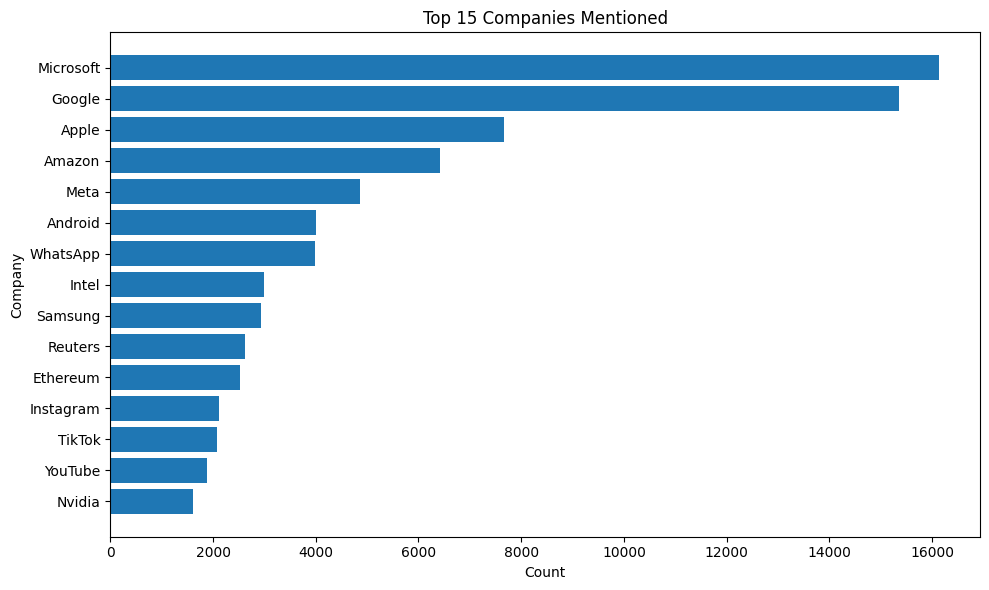

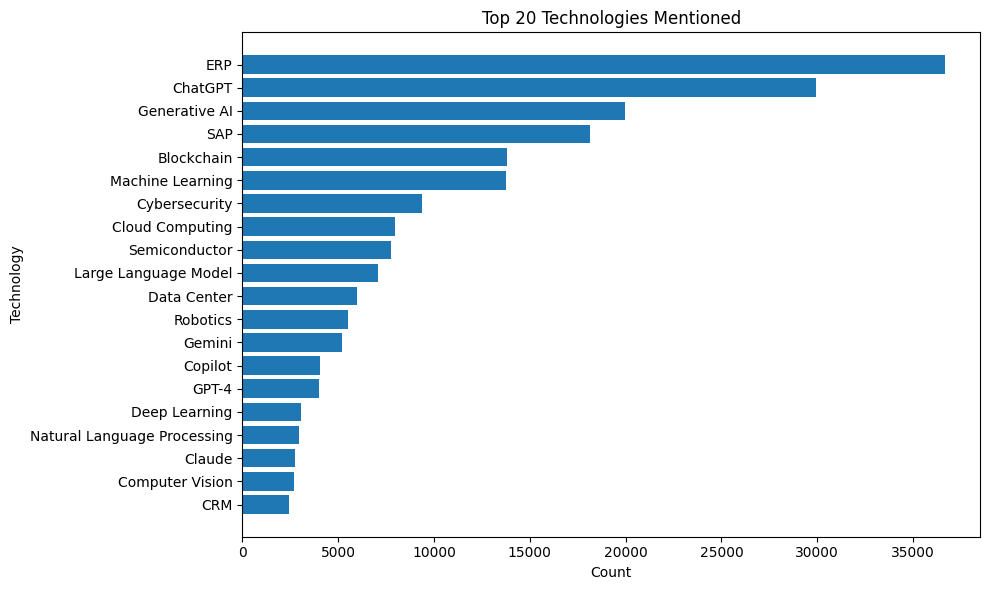

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

all_companies_clean = Counter(
    company
    for sublist in df_news_final_project["companies_clean"]
    if isinstance(sublist, list)
    for company in sublist
)

top_n_companies = 15
top_companies_df = pd.DataFrame(
    all_companies_clean.most_common(top_n_companies),
    columns=["Company", "Count"]
)

plt.figure(figsize=(10, 6))
plt.barh(top_companies_df["Company"][::-1], top_companies_df["Count"][::-1])
plt.xlabel("Count")
plt.ylabel("Company")
plt.title(f"Top {top_n_companies} Companies Mentioned")
plt.tight_layout()
plt.show()


all_technologies = Counter(
    tech
    for sublist in df_news_final_project["technologies"]
    if isinstance(sublist, list)
    for tech in sublist
)

top_n_technologies = 20
top_technologies_df = pd.DataFrame(
    all_technologies.most_common(top_n_technologies),
    columns=["Technology", "Count"]
)

plt.figure(figsize=(10, 6))
plt.barh(top_technologies_df["Technology"][::-1], top_technologies_df["Count"][::-1])
plt.xlabel("Count")
plt.ylabel("Technology")
plt.title(f"Top {top_n_technologies} Technologies Mentioned")
plt.tight_layout()
plt.show()

In [ ]:
df_news_final_project.to_parquet(
    "/content/drive/MyDrive/NLP_AI_Impact_Project/data/entities_extracted.parquet"
)